# Week 2: Contextual Data Fusion and Feature Engineering

## Introduction

The objective of Week 2 is to enrich the machine sensor data by incorporating contextual environmental information that may influence machine performance and failure. While internal IoT sensor readings provide valuable insights into machine health, external operating conditions such as ambient temperature, humidity, factory load, and work shifts can also impact equipment reliability.

In this phase, contextual features are simulated and integrated with the existing dataset to create a comprehensive data fusion pipeline. Additional engineered features are then generated to capture interactions between internal sensor measurements and external operating conditions. Finally, an ablation study is conducted to compare the predictive performance of models trained with and without contextual features.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [4]:
df=pd.read_csv(r"C:\Users\tange\week1_processed_data.csv")

In [5]:
df

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Torque_RollingMean,Torque_RollingStd,Torque_RollingVar,...,RPM_RollingStd,RPM_RollingVar,ToolWear_RollingMean,ToolWear_RollingStd,ToolWear_RollingVar,Temp_Difference,Power_Index,Wear_Torque,Temp_Ratio,RPM_per_Torque
0,1,298.2,308.7,1408,40.0,9,0,43.60,4.223150,17.835,...,62.970628,3965.3,4.8,3.492850,12.2,10.5,56320.0,360.0,1.035211,34.341463
1,2,298.1,308.6,1425,41.9,11,0,43.42,4.284507,18.357,...,37.179295,1382.3,7.0,3.162278,10.0,10.5,59707.5,460.9,1.035223,33.216783
2,1,298.1,308.6,1558,42.4,14,0,42.64,3.972782,15.783,...,62.468392,3902.3,9.2,3.492850,12.2,10.5,66059.2,593.6,1.035223,35.898618
3,1,298.1,308.6,1527,40.2,16,0,40.80,1.270827,1.615,...,67.510740,4557.7,11.4,3.646917,13.3,10.5,61385.4,643.2,1.035223,37.063107
4,2,298.3,308.7,1667,28.6,18,0,38.62,5.697543,32.462,...,105.624334,11156.5,13.6,3.646917,13.3,10.4,47676.2,514.8,1.034864,56.317568
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9991,2,298.8,308.4,1604,29.5,14,0,34.00,8.997222,80.950,...,162.217447,26314.5,9.8,3.492850,12.2,9.6,47318.0,413.0,1.032129,52.590164
9992,0,298.9,308.4,1632,31.8,17,0,35.14,8.058102,64.933,...,103.980767,10812.0,12.2,3.492850,12.2,9.5,51897.6,540.6,1.031783,49.756098
9993,2,299.0,308.6,1645,33.4,22,0,33.98,7.738669,59.887,...,102.969413,10602.7,15.0,4.690416,22.0,9.6,54943.0,734.8,1.032107,47.819767
9994,0,299.0,308.7,1408,48.5,25,0,34.22,8.256331,68.167,...,99.873921,9974.8,18.0,5.431390,29.5,9.7,68288.0,1212.5,1.032441,28.444444


In [6]:
np.random.seed(42)

df['Ambient_Temperature'] = np.random.normal(30, 4, len(df))

df['Humidity'] = np.random.randint(40, 90, len(df))

df['Factory_Load'] = np.random.uniform(0.5, 1.0, len(df))

df['Shift'] = np.random.choice(
    ['Morning', 'Evening', 'Night'],
    len(df)
)

In [7]:
df

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Torque_RollingMean,Torque_RollingStd,Torque_RollingVar,...,ToolWear_RollingVar,Temp_Difference,Power_Index,Wear_Torque,Temp_Ratio,RPM_per_Torque,Ambient_Temperature,Humidity,Factory_Load,Shift
0,1,298.2,308.7,1408,40.0,9,0,43.60,4.223150,17.835,...,12.2,10.5,56320.0,360.0,1.035211,34.341463,31.986857,68,0.782904,Evening
1,2,298.1,308.6,1425,41.9,11,0,43.42,4.284507,18.357,...,10.0,10.5,59707.5,460.9,1.035223,33.216783,29.446943,61,0.962677,Night
2,1,298.1,308.6,1558,42.4,14,0,42.64,3.972782,15.783,...,12.2,10.5,66059.2,593.6,1.035223,35.898618,32.590754,59,0.512720,Evening
3,1,298.1,308.6,1527,40.2,16,0,40.80,1.270827,1.615,...,13.3,10.5,61385.4,643.2,1.035223,37.063107,36.092119,45,0.854098,Night
4,2,298.3,308.7,1667,28.6,18,0,38.62,5.697543,32.462,...,13.3,10.4,47676.2,514.8,1.034864,56.317568,29.063387,82,0.665164,Morning
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9991,2,298.8,308.4,1604,29.5,14,0,34.00,8.997222,80.950,...,12.2,9.6,47318.0,413.0,1.032129,52.590164,30.765803,79,0.672882,Morning
9992,0,298.9,308.4,1632,31.8,17,0,35.14,8.058102,64.933,...,12.2,9.5,51897.6,540.6,1.031783,49.756098,32.648675,52,0.713745,Night
9993,2,299.0,308.6,1645,33.4,22,0,33.98,7.738669,59.887,...,22.0,9.6,54943.0,734.8,1.032107,47.819767,24.005458,62,0.863355,Evening
9994,0,299.0,308.7,1408,48.5,25,0,34.22,8.256331,68.167,...,29.5,9.7,68288.0,1212.5,1.032441,28.444444,34.776858,43,0.605792,Night


In [8]:
from sklearn.preprocessing import LabelEncoder

shift_encoder = LabelEncoder()

df['Shift'] = shift_encoder.fit_transform(df['Shift'])

In [9]:
df

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Torque_RollingMean,Torque_RollingStd,Torque_RollingVar,...,ToolWear_RollingVar,Temp_Difference,Power_Index,Wear_Torque,Temp_Ratio,RPM_per_Torque,Ambient_Temperature,Humidity,Factory_Load,Shift
0,1,298.2,308.7,1408,40.0,9,0,43.60,4.223150,17.835,...,12.2,10.5,56320.0,360.0,1.035211,34.341463,31.986857,68,0.782904,0
1,2,298.1,308.6,1425,41.9,11,0,43.42,4.284507,18.357,...,10.0,10.5,59707.5,460.9,1.035223,33.216783,29.446943,61,0.962677,2
2,1,298.1,308.6,1558,42.4,14,0,42.64,3.972782,15.783,...,12.2,10.5,66059.2,593.6,1.035223,35.898618,32.590754,59,0.512720,0
3,1,298.1,308.6,1527,40.2,16,0,40.80,1.270827,1.615,...,13.3,10.5,61385.4,643.2,1.035223,37.063107,36.092119,45,0.854098,2
4,2,298.3,308.7,1667,28.6,18,0,38.62,5.697543,32.462,...,13.3,10.4,47676.2,514.8,1.034864,56.317568,29.063387,82,0.665164,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9991,2,298.8,308.4,1604,29.5,14,0,34.00,8.997222,80.950,...,12.2,9.6,47318.0,413.0,1.032129,52.590164,30.765803,79,0.672882,1
9992,0,298.9,308.4,1632,31.8,17,0,35.14,8.058102,64.933,...,12.2,9.5,51897.6,540.6,1.031783,49.756098,32.648675,52,0.713745,2
9993,2,299.0,308.6,1645,33.4,22,0,33.98,7.738669,59.887,...,22.0,9.6,54943.0,734.8,1.032107,47.819767,24.005458,62,0.863355,0
9994,0,299.0,308.7,1408,48.5,25,0,34.22,8.256331,68.167,...,29.5,9.7,68288.0,1212.5,1.032441,28.444444,34.776858,43,0.605792,2


In [10]:
df['Heat_Stress'] = (
    df['Ambient_Temperature']
    * df['Process temperature [K]']
)

df['Load_Torque'] = (
    df['Factory_Load']
    * df['Torque [Nm]']
)

df['Humidity_Wear'] = (
    df['Humidity']
    * df['Tool wear [min]']
)

df['Temp_Load'] = (
    df['Ambient_Temperature']
    * df['Factory_Load']
)

In [11]:
df

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Torque_RollingMean,Torque_RollingStd,Torque_RollingVar,...,Temp_Ratio,RPM_per_Torque,Ambient_Temperature,Humidity,Factory_Load,Shift,Heat_Stress,Load_Torque,Humidity_Wear,Temp_Load
0,1,298.2,308.7,1408,40.0,9,0,43.60,4.223150,17.835,...,1.035211,34.341463,31.986857,68,0.782904,0,9874.342636,31.316173,612,25.042648
1,2,298.1,308.6,1425,41.9,11,0,43.42,4.284507,18.357,...,1.035223,33.216783,29.446943,61,0.962677,2,9087.326547,40.336185,671,28.347908
2,1,298.1,308.6,1558,42.4,14,0,42.64,3.972782,15.783,...,1.035223,35.898618,32.590754,59,0.512720,0,10057.506731,21.739347,826,16.709946
3,1,298.1,308.6,1527,40.2,16,0,40.80,1.270827,1.615,...,1.035223,37.063107,36.092119,45,0.854098,2,11138.028055,34.334738,720,30.826206
4,2,298.3,308.7,1667,28.6,18,0,38.62,5.697543,32.462,...,1.034864,56.317568,29.063387,82,0.665164,1,8971.867413,19.023686,1476,19.331914
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9991,2,298.8,308.4,1604,29.5,14,0,34.00,8.997222,80.950,...,1.032129,52.590164,30.765803,79,0.672882,1,9488.173603,19.850022,1106,20.701758
9992,0,298.9,308.4,1632,31.8,17,0,35.14,8.058102,64.933,...,1.031783,49.756098,32.648675,52,0.713745,2,10068.851375,22.697085,884,23.302823
9993,2,299.0,308.6,1645,33.4,22,0,33.98,7.738669,59.887,...,1.032107,47.819767,24.005458,62,0.863355,0,7408.084342,28.836052,1364,20.725228
9994,0,299.0,308.7,1408,48.5,25,0,34.22,8.256331,68.167,...,1.032441,28.444444,34.776858,43,0.605792,2,10735.616044,29.380908,1075,21.067539


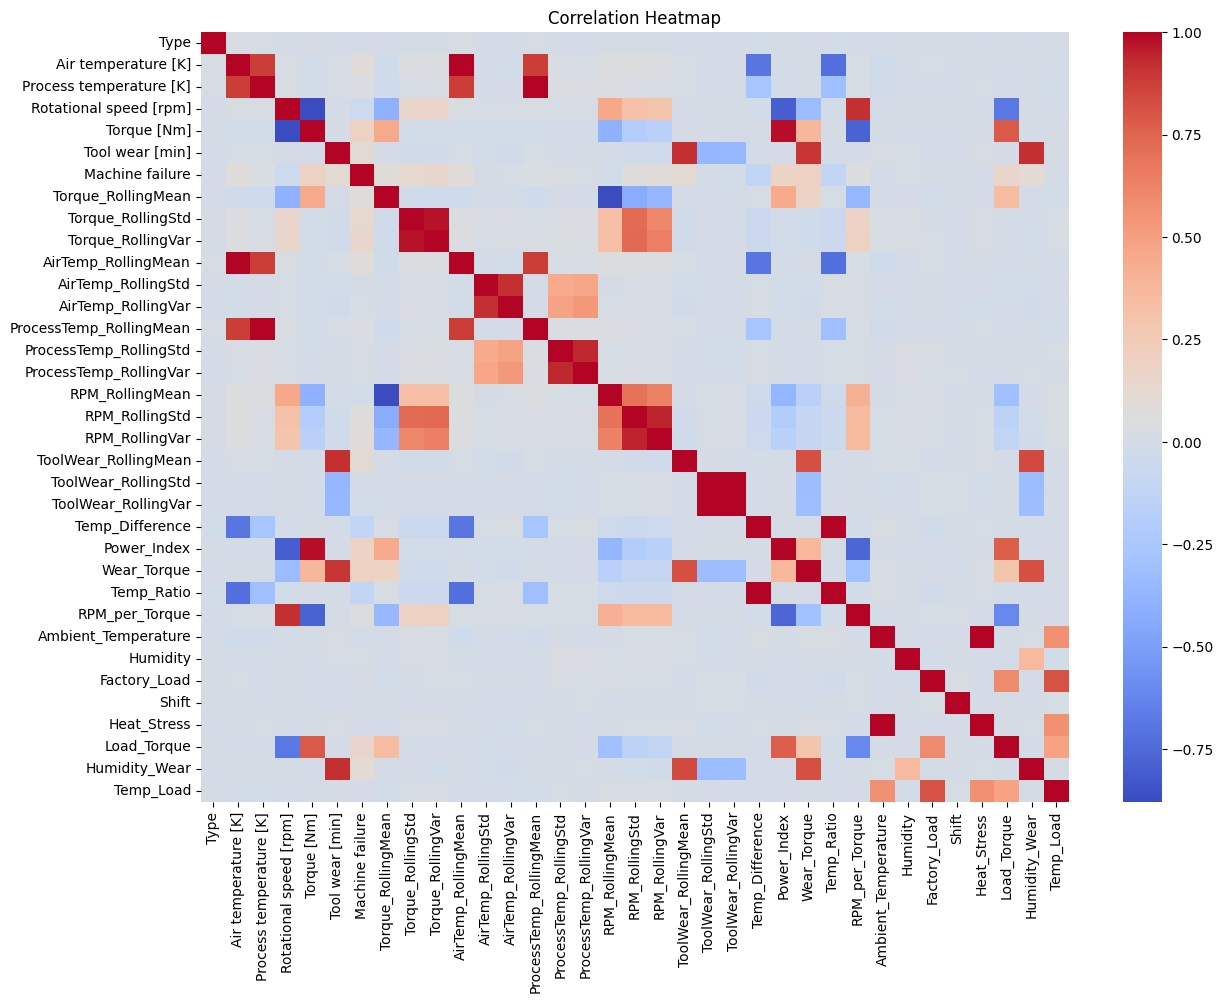

In [12]:
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(numeric_only=True),
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

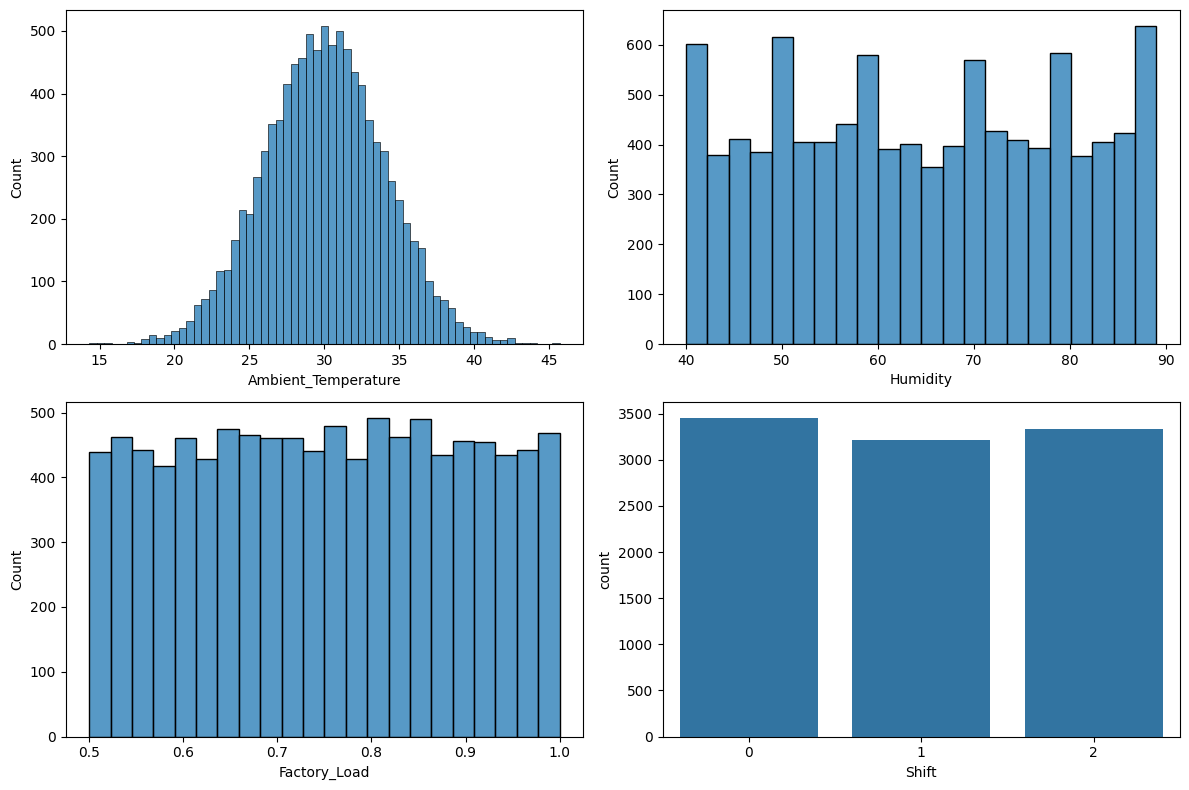

In [13]:
fig, axes = plt.subplots(2,2, figsize=(12,8))

sns.histplot(df['Ambient_Temperature'], ax=axes[0,0])

sns.histplot(df['Humidity'], ax=axes[0,1])

sns.histplot(df['Factory_Load'], ax=axes[1,0])

sns.countplot(x=df['Shift'], ax=axes[1,1])

plt.tight_layout()

plt.show()